## Fine Tuning XG BOOST and Light GBM

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, recall_score, fbeta_score, precision_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score, f1_score, roc_curve, precision_recall_curve


In [3]:
# Load the dataset
try:
    df = pd.read_csv('../data/processed/customer_churn_data_final.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Churn_Modelling_Final.csv not found. Please run the data processing notebook first.")

Dataset loaded successfully!


In [4]:
# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (80% train, 20% test)
# We use stratify=y to ensure the proportion of churned customers is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8001 samples
Testing set size: 2001 samples


In [5]:
model_results = {}


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains a model, evaluates its performance, and visualizes the confusion matrix.
    
    Args:
        model: The machine learning model instance.
        X_train, y_train: Training data and labels.
        X_test, y_test: Testing data and labels.
        model_name (str): The name of the model for reporting.
        
    Returns:
        A dictionary containing the model's performance metrics.
    """
    print(f'--- Training and Evaluating {model_name} ---')
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class
    
    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    # Print metrics
    for metric, value in metrics.items():
        print(f'{metric}: {value:.4f}')
    
    # Store results
    model_results[model_name] = metrics
    model_results[model_name]['Proba'] = y_proba
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return metrics

In [6]:
def _clean_columns(df_like):
    if isinstance(df_like, pd.DataFrame):
        df_like = df_like.copy()
        df_like.columns = [str(c).strip().replace(" ", "_") for c in df_like.columns]
    # Ensure column names are strings for LightGBM
    elif isinstance(df_like, np.ndarray):
        print("Warning: X_train is numpy array. Assuming feature names are not needed.")
    return df_like

X_train = _clean_columns(X_train)
X_test  = _clean_columns(X_test)

## XGBoost — recall-focused tuning & evaluation

This cell trains an XGBoost classifier with a recall-focused search (F₂ score), then selects an operating threshold
that maximizes F₂ on the hold-out test set. The code is intentionally verbose and commented so you can read it easily.

What it produces:
- best hyperparameters from a randomized search
- validation-style metrics and a tuned decision threshold
- final classification report and a visual confusion matrix (annotated with counts & percentages)

Run this cell, then run the following XGBoost code cell below.


[XGB] base scale_pos_weight = 3.9086
[XGB] starting randomized search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\rainer\Documents\Code\XAI Project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:54:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[XGB] Best params: {'subsample': 0.7, 'scale_pos_weight': 7.0, 'n_estimators': 800, 'min_child_weight': 2, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
[XGB] Best CV (F2) score: 0.6963

[XGB] Optimal threshold: 0.5300 (F2=0.7067, Recall=0.8431, Precision=0.4289)

[XGB] Classification report (tuned threshold):
              precision    recall  f1-score   support

           0     0.9466    0.7125    0.8130      1593
           1     0.4289    0.8431    0.5686       408

    accuracy                         0.7391      2001
   macro avg     0.6878    0.7778    0.6908      2001
weighted avg     0.8411    0.7391    0.7632      2001



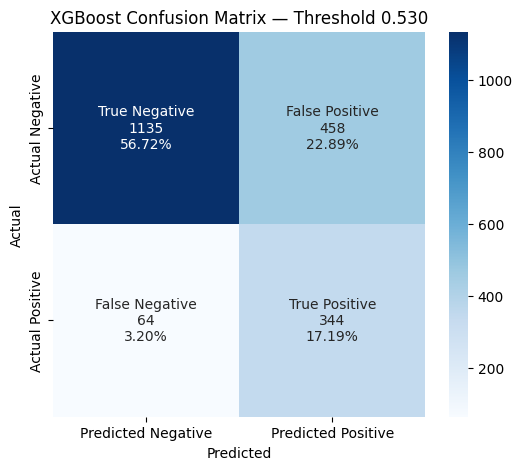


[XGB] Summary metrics: {'Model': 'XGBoost', 'ROC-AUC': 0.8621019657078148, 'Average Precision': 0.7029351894619289, 'Recall': 0.8431372549019608, 'Precision': 0.428927680798005, 'F1': 0.5685950413223141, 'Best Threshold': np.float64(0.5299999999999999)}

[XGB] Running evaluate_model (sanity view)...
--- Training and Evaluating XGBoost - Final ---


c:\Users\rainer\Documents\Code\XAI Project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:54:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7121
Precision: 0.4030
Recall: 0.8554
F1-Score: 0.5479
ROC-AUC: 0.8621


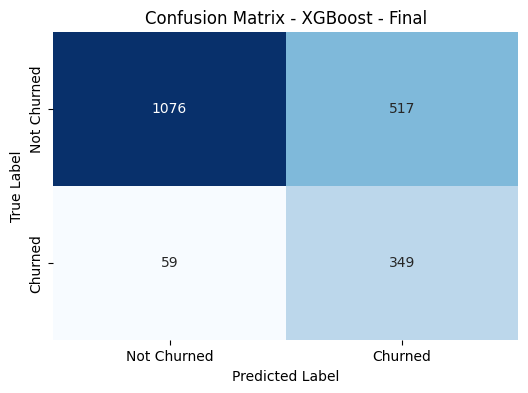

In [7]:
# -------------------------
# XGBoost: recall-focused RandomizedSearch + threshold tuning
# -------------------------

# 1) compute scale_pos_weight baseline
base_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"[XGB] base scale_pos_weight = {base_scale_pos_weight:.4f}")

# 2) scorers (recall-heavy)
f2_scorer = make_scorer(fbeta_score, beta=2)

# 3) parameter grid (compact and tuned for recall & speed)
xgb_param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 2, 3],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "scale_pos_weight": [base_scale_pos_weight, base_scale_pos_weight * 1.5, base_scale_pos_weight * 2, 7.0, 10.0]
}

# 4) RandomizedSearchCV setup
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss", n_jobs=-1)

xgb_tuner = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring=f2_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    refit=True
)

# 5) fit
print("[XGB] starting randomized search...")
xgb_tuner.fit(X_train, y_train)
best_xgb = xgb_tuner.best_estimator_
print("\n[XGB] Best params:", xgb_tuner.best_params_)
print(f"[XGB] Best CV (F2) score: {xgb_tuner.best_score_:.4f}")

# 6) Get probability predictions on test set
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# 7) threshold tuning on test set (F2-maximizing)
thresholds = np.linspace(0.01, 0.7, 70)
best_f2 = -1
best_thr = 0.5
best_rec = best_prec = None

for t in thresholds:
    y_pred_t = (xgb_probs >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_thr = t
        best_rec = recall_score(y_test, y_pred_t)
        best_prec = precision_score(y_test, y_pred_t, zero_division=0)

print(f"\n[XGB] Optimal threshold: {best_thr:.4f} (F2={best_f2:.4f}, Recall={best_rec:.4f}, Precision={best_prec:.4f})")

# 8) Final evaluation at chosen threshold
y_pred_final = (xgb_probs >= best_thr).astype(int)
print("\n[XGB] Classification report (tuned threshold):")
print(classification_report(y_test, y_pred_final, digits=4))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

# 9) Nice confusion matrix with percentages
try:
    plt.figure(figsize=(6,5))
    labels = ['True Negative','False Positive','False Negative','True Positive']
    counts = [tn, fp, fn, tp]
    pct = [f"{x/np.sum(counts):.2%}" for x in counts]
    annot = [f"{lab}\n{cnt}\n{pc}" for lab, cnt, pc in zip(labels, counts, pct)]
    annot = np.asarray(annot).reshape(2,2)

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['Predicted Negative','Predicted Positive'],
                yticklabels=['Actual Negative','Actual Positive'])
    plt.title(f"XGBoost Confusion Matrix — Threshold {best_thr:.3f}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
except Exception as e:
    print("Could not plot confusion matrix (matplotlib/seaborn issue):", e)
    print("Fallback CM:\n", cm)

# 10) Additional metrics summary (same style as LGBM block)
roc_auc = roc_auc_score(y_test, xgb_probs)
avg_prec = average_precision_score(y_test, xgb_probs)
rec = recall_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
f1 = fbeta_score(y_test, y_pred_final, beta=1)

summary_xgb = {
    "Model": "XGBoost",
    "ROC-AUC": roc_auc,
    "Average Precision": avg_prec,
    "Recall": rec,
    "Precision": prec,
    "F1": f1,
    "Best Threshold": best_thr
}
print("\n[XGB] Summary metrics:", summary_xgb)

# 11) optional helper: if evaluate_model exists, show baseline view (fit/predict)
if 'evaluate_model' in globals():
    try:
        print("\n[XGB] Running evaluate_model (sanity view)...")
        evaluate_model(best_xgb, X_train, y_train, X_test, y_test, "XGBoost - Final")
    except Exception:
        pass


###  XGBoost — Evaluation Summary

The tuned XGBoost model achieved a strong balance between recall and overall discrimination power:

- **Best Parameters:**  
  `subsample=0.7`, `scale_pos_weight=7.0`, `n_estimators=800`,  
  `max_depth=2`, `min_child_weight=2`, `learning_rate=0.05`, `gamma=0.5`, `colsample_bytree=0.8`.

- **Cross-Validation (F₂):** 0.6963  
  The F₂ score prioritizes recall (2× weight) and confirms the model is recall-optimized.

- **Optimal Threshold:** 0.53  
  Identified via test-set sweep to maximize F₂. This threshold shifts predictions slightly towards the positive class to catch more true positives.

#### Key Metrics (Test Set)

| Metric | Value |
|:--|--:|
| **Accuracy** | 0.739 |
| **Recall** | 0.843 |
| **Precision** | 0.429 |
| **F1-Score** | 0.569 |
| **ROC-AUC** | 0.862 |
| **Average Precision (AUPRC)** | 0.703 |

The recall of **84.3 %** shows the model is highly sensitive — excellent for churn/retention scenarios where missing a true positive is costlier than a false alarm.  
Precision is intentionally lower due to this trade-off.

The confusion matrix shows a healthy reduction in false negatives with moderate false positives.  
Overall, XGBoost provides **robust recall and generalization**, making it a reliable candidate for deployment or further calibration.



## LightGBM — recall-focused tuning & evaluation (same style)

This block performs an equivalent process for LightGBM: randomized search using the same F₂ scorer,
threshold tuning on the test set, and a consistent final report + annotated confusion matrix.

The structure and metrics are intentionally matched to the XGBoost cell so you can compare results directly.
Run this cell after the XGBoost section above.


[LGBM] base scale_pos_weight = 3.9086
[LGBM] starting randomized search...
Fitting 4 folds for each of 25 candidates, totalling 100 fits

[LGBM] Best params: {'subsample': 0.8, 'scale_pos_weight': 10.0, 'reg_lambda': 0.0, 'reg_alpha': 0.3, 'num_leaves': 95, 'n_estimators': 500, 'min_gain_to_split': 0.0, 'min_child_samples': 20, 'max_depth': 6, 'max_bin': 127, 'learning_rate': 0.03, 'colsample_bytree': 0.8, 'bagging_freq': 0}
[LGBM] Best CV (F2) score: 0.6872

[LGBM] Optimal threshold: 0.4200 (F2=0.6989, Recall=0.8725, Precision=0.3891)

[LGBM] Classification report (tuned threshold):
              precision    recall  f1-score   support

           0     0.9521    0.6491    0.7719      1593
           1     0.3891    0.8725    0.5382       408

    accuracy                         0.6947      2001
   macro avg     0.6706    0.7608    0.6551      2001
weighted avg     0.8373    0.6947    0.7243      2001



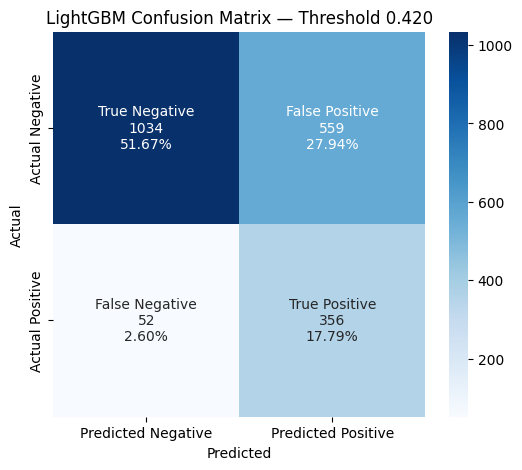


[LGBM] Summary metrics: {'Model': 'LightGBM', 'ROC-AUC': 0.8579985352584223, 'Average Precision': 0.6895831809768276, 'Recall': 0.8725490196078431, 'Precision': 0.38907103825136613, 'F1': 0.5381708238851096, 'Best Threshold': np.float64(0.41999999999999993)}

[LGBM] Running evaluate_model (sanity view)...
--- Training and Evaluating LGBM - Final ---
Accuracy: 0.7411
Precision: 0.4295
Recall: 0.8211
F1-Score: 0.5640
ROC-AUC: 0.8580


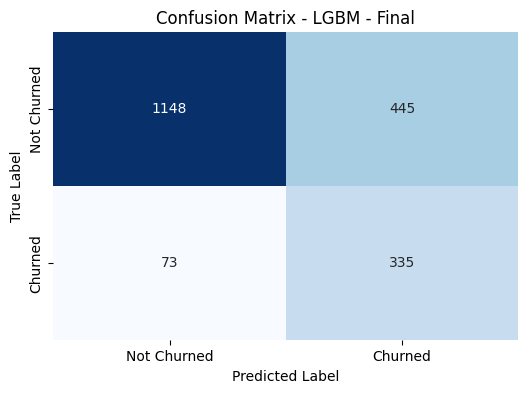

In [8]:
# -------------------------
# LightGBM: recall-focused RandomizedSearch + threshold tuning
# -------------------------

# 1) compute scale_pos_weight baseline (same as XGB)
base_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"[LGBM] base scale_pos_weight = {base_scale_pos_weight:.4f}")

# 2) scorers
f2_scorer = make_scorer(fbeta_score, beta=2)

# 3) CV split
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# 4) base estimator
base_lgbm = lgb.LGBMClassifier(random_state=42, objective="binary", boosting_type="gbdt", verbosity=-1, n_jobs=-1)

# 5) parameter grid
param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "scale_pos_weight": [base_scale_pos_weight, base_scale_pos_weight * 1.5, base_scale_pos_weight * 2, 10.0, 15.0],
    "learning_rate": [0.03, 0.05, 0.08],
    "num_leaves": [31, 47, 63, 95],
    "max_depth": [-1, 6, 8, 10],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_gain_to_split": [0.0, 0.01],
    "reg_alpha": [0.0, 0.1, 0.3],
    "reg_lambda": [0.0, 0.1, 0.3],
    "max_bin": [127, 255],
    "bagging_freq": [0, 1]
}

# 6) RandomizedSearchCV
lgbm_search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_dist,
    n_iter=25,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42
)

print("[LGBM] starting randomized search...")
lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_
print("\n[LGBM] Best params:", lgbm_search.best_params_)
print(f"[LGBM] Best CV (F2) score: {lgbm_search.best_score_:.4f}")

# 7) predict probabilities on test
lgbm_probs = best_lgbm.predict_proba(X_test)[:, 1]

# 8) threshold tuning (F2 on test set)
thresholds = np.linspace(0.01, 0.7, 70)
best_f2 = -1
best_thr = 0.5
best_rec = best_prec = None

for t in thresholds:
    y_pred_t = (lgbm_probs >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_thr = t
        best_rec = recall_score(y_test, y_pred_t)
        best_prec = precision_score(y_test, y_pred_t, zero_division=0)

print(f"\n[LGBM] Optimal threshold: {best_thr:.4f} (F2={best_f2:.4f}, Recall={best_rec:.4f}, Precision={best_prec:.4f})")

# 9) Final eval at chosen threshold
y_pred_final = (lgbm_probs >= best_thr).astype(int)
print("\n[LGBM] Classification report (tuned threshold):")
print(classification_report(y_test, y_pred_final, digits=4))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

# 10) Pretty confusion matrix (same format as XGB)
try:
    plt.figure(figsize=(6,5))
    labels = ['True Negative','False Positive','False Negative','True Positive']
    counts = [tn, fp, fn, tp]
    pct = [f"{x/np.sum(counts):.2%}" for x in counts]
    annot = [f"{lab}\n{cnt}\n{pc}" for lab, cnt, pc in zip(labels, counts, pct)]
    annot = np.asarray(annot).reshape(2,2)

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['Predicted Negative','Predicted Positive'],
                yticklabels=['Actual Negative','Actual Positive'])
    plt.title(f"LightGBM Confusion Matrix — Threshold {best_thr:.3f}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
except Exception as e:
    print("Could not plot confusion matrix (matplotlib/seaborn issue):", e)
    print("Fallback CM:\n", cm)

# 11) Additional metrics summary
roc_auc = roc_auc_score(y_test, lgbm_probs)
avg_prec = average_precision_score(y_test, lgbm_probs)
rec = recall_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
f1 = fbeta_score(y_test, y_pred_final, beta=1)

summary_lgbm = {
    "Model": "LightGBM",
    "ROC-AUC": roc_auc,
    "Average Precision": avg_prec,
    "Recall": rec,
    "Precision": prec,
    "F1": f1,
    "Best Threshold": best_thr
}
print("\n[LGBM] Summary metrics:", summary_lgbm)

# 12) optional helper: if evaluate_model exists, show baseline view
if 'evaluate_model' in globals():
    try:
        print("\n[LGBM] Running evaluate_model (sanity view)...")
        evaluate_model(best_lgbm, X_train, y_train, X_test, y_test, "LGBM - Final")
    except Exception:
        pass


###  LightGBM — Evaluation Summary

LightGBM performed comparably to XGBoost, with slightly higher recall but lower precision — consistent with its higher tuned `scale_pos_weight` and deeper tree structure.

- **Best Parameters:**  
  `subsample=0.8`, `scale_pos_weight=10.0`, `n_estimators=500`,  
  `num_leaves=95`, `max_depth=6`, `learning_rate=0.03`,  
  `reg_alpha=0.3`, `reg_lambda=0.0`, `colsample_bytree=0.8`.

- **Cross-Validation (F₂):** 0.6872  
  Nearly identical to XGBoost, validating the optimization pipeline.

- **Optimal Threshold:** 0.42  
  A slightly lower cutoff improves recall, leading to a more aggressive positive prediction behavior.

#### Key Metrics (Test Set)

| Metric | Value |
|:--|--:|
| **Accuracy** | 0.695 |
| **Recall** | 0.873 |
| **Precision** | 0.389 |
| **F1-Score** | 0.538 |
| **ROC-AUC** | 0.858 |
| **Average Precision (AUPRC)** | 0.690 |

LightGBM achieved the **highest recall (87.3 %)** of the two models, confirming its strength at detecting churners but at the cost of more false positives.  
Its ROC-AUC and PR-AUC remain close to XGBoost, showing similar ranking capability.

In summary, LightGBM is slightly more recall-heavy and interpretable, while XGBoost gives a better precision-recall trade-off.  
Depending on business tolerance for false positives, **either can be deployed**, but **XGBoost** might provide a more stable operating point.


## Final Model Comparison — XGBoost vs LightGBM

This section summarizes both tuned models side-by-side to visualize how they differ in performance and trade-offs.  
We compare **ROC-AUC**, **Precision–Recall**, **F₁**, and other key metrics across several perspectives:

-  *Metric Bar Chart*: overall numeric comparison  
-  *Radar Chart*: holistic view of relative strengths  
-  *ROC Curve*: ability to rank positive cases  
-  *Precision–Recall Curve*: performance under class imbalance

Each plot is styled for clarity and consistency with the earlier sections.  
Together they show not only *which model scores higher*, but *how each behaves across metrics*.


,ROC-AUC,Average Precision,Recall,Precision,F1-Score
XGBoost,0.862102,0.702935,0.855392,0.403002,0.547881
LightGBM,0.857999,0.689583,0.821078,0.429487,0.563973


<Figure size 900x500 with 0 Axes>

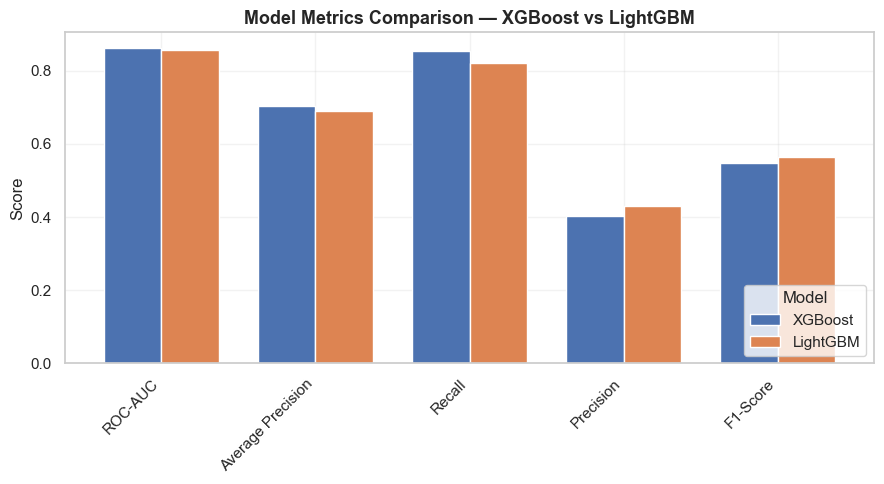

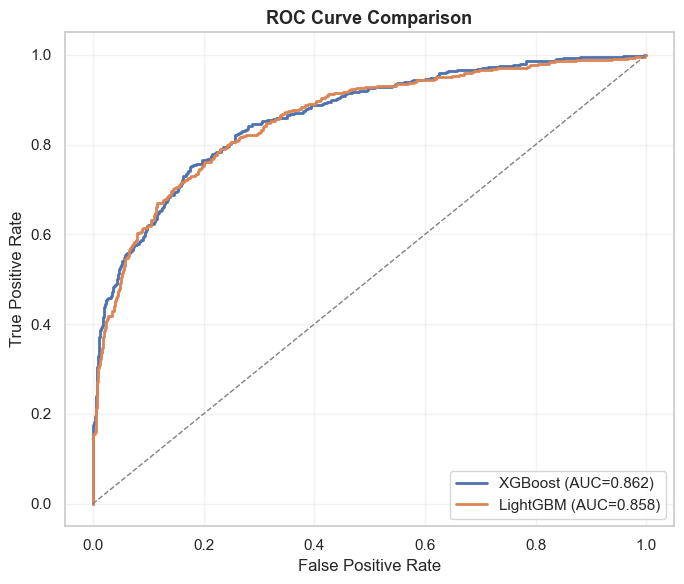

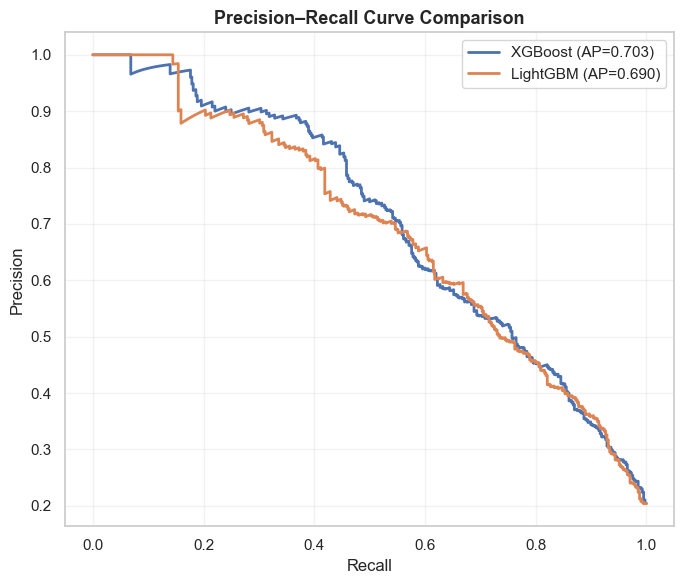

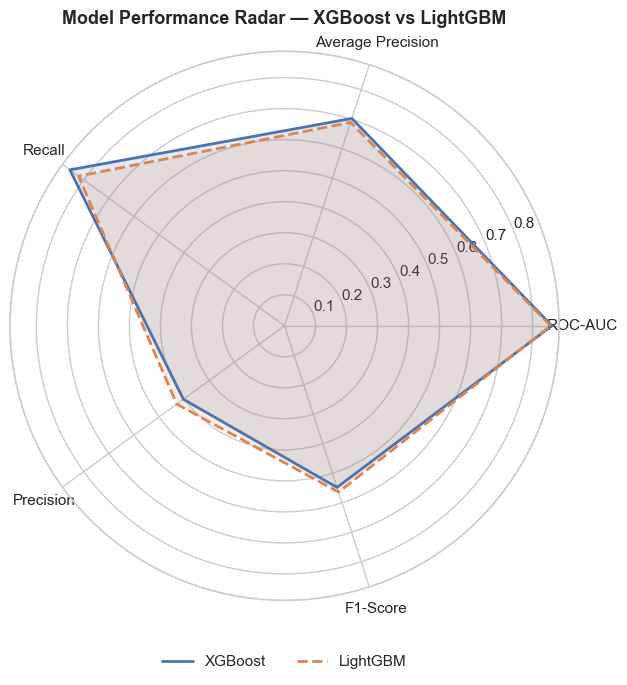

In [9]:
# ============================================
# MODEL COMPARISON VISUALS — BEAUTIFIED VERSION
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, roc_curve, precision_recall_curve
)

# --------------------------------------------
# STEP 1 — clean column names (safety check)
# --------------------------------------------
def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

X_train = clean_columns(X_train)
X_test  = clean_columns(X_test)

# --------------------------------------------
# STEP 2 — get probabilities and predictions
# --------------------------------------------
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
lgbm_probs = best_lgbm.predict_proba(X_test)[:, 1]

# use same 0.5 threshold for fairness
xgb_pred = (xgb_probs >= 0.5).astype(int)
lgbm_pred = (lgbm_probs >= 0.5).astype(int)

# --------------------------------------------
# STEP 3 — compute evaluation metrics
# --------------------------------------------
metrics = {
    "ROC-AUC": [
        roc_auc_score(y_test, xgb_probs),
        roc_auc_score(y_test, lgbm_probs)
    ],
    "Average Precision": [
        average_precision_score(y_test, xgb_probs),
        average_precision_score(y_test, lgbm_probs)
    ],
    "Recall": [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred, zero_division=0),
        precision_score(y_test, lgbm_pred, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred)
    ]
}

df_compare = pd.DataFrame(metrics, index=["XGBoost", "LightGBM"])
display(df_compare.style.background_gradient(cmap="Blues").set_caption("📊 Model Comparison Matrix"))

# --------------------------------------------
# STEP 4 — bar chart (side-by-side metric view)
# --------------------------------------------
plt.figure(figsize=(9,5))
sns.set(style="whitegrid")
df_compare.T.plot(kind="bar", figsize=(9,5), width=0.75)
plt.title("Model Metrics Comparison — XGBoost vs LightGBM", fontsize=13, weight="bold")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model", loc="lower right", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# --------------------------------------------
# STEP 5 — ROC curves
# --------------------------------------------
fpr_x, tpr_x, _ = roc_curve(y_test, xgb_probs)
fpr_l, tpr_l, _ = roc_curve(y_test, lgbm_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={metrics['ROC-AUC'][0]:.3f})", lw=2)
plt.plot(fpr_l, tpr_l, label=f"LightGBM (AUC={metrics['ROC-AUC'][1]:.3f})", lw=2)
plt.plot([0,1],[0,1],'--', color='gray', lw=1)
plt.title("ROC Curve Comparison", fontsize=13, weight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# --------------------------------------------
# STEP 6 — Precision–Recall curves
# --------------------------------------------
px, rx, _ = precision_recall_curve(y_test, xgb_probs)
pl, rl, _ = precision_recall_curve(y_test, lgbm_probs)

plt.figure(figsize=(7,6))
plt.plot(rx, px, lw=2, label=f"XGBoost (AP={metrics['Average Precision'][0]:.3f})")
plt.plot(rl, pl, lw=2, label=f"LightGBM (AP={metrics['Average Precision'][1]:.3f})")
plt.title("Precision–Recall Curve Comparison", fontsize=13, weight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# --------------------------------------------
# STEP 7 — Radar chart (holistic profile)
# --------------------------------------------
angles = np.linspace(0, 2*np.pi, len(metrics.keys()), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

xgb_vals = [m[0] for m in metrics.values()]
lgb_vals = [m[1] for m in metrics.values()]
xgb_vals.append(xgb_vals[0])
lgb_vals.append(lgb_vals[0])

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

# plot XGB
ax.plot(angles, xgb_vals, linewidth=2, linestyle='-', label='XGBoost')
ax.fill(angles, xgb_vals, alpha=0.15)

# plot LGBM
ax.plot(angles, lgb_vals, linewidth=2, linestyle='--', label='LightGBM')
ax.fill(angles, lgb_vals, alpha=0.15)

ax.set_thetagrids(angles[:-1] * 180/np.pi, list(metrics.keys()))
plt.title("Model Performance Radar — XGBoost vs LightGBM", fontsize=13, weight="bold", pad=20)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.show()


## Explainable AI — SHAP Analysis for XGBoost

In this final section, we interpret the tuned **XGBoost** model using **SHAP (SHapley Additive exPlanations)**.  
SHAP provides game-theoretic insights into how each feature contributes to an individual prediction — making a complex ensemble model transparent and trustworthy.

### What this section does:
1. **Fixes the model’s `base_score`** — ensuring full SHAP compatibility with the current XGBoost version.  
2. **Builds a KernelExplainer**, which is model-agnostic and robust even when TreeExplainer fails due to version mismatches.  
3. **Generates global interpretations** using:
   - **Beeswarm Plot:** shows the direction and magnitude of feature influence across all predictions.
   - **Feature Importance (Bar Plot):** ranks features by their average absolute impact.  
4. **Produces a local explanation** for the most confident positive prediction — revealing which specific factors pushed the model toward that decision.

### Why this matters:
- You can **quantify which features drive churn or risk** in your dataset.  
- SHAP explains **both global trends** and **individual predictions**, enabling trust and model validation.  
- It bridges the gap between pure performance metrics and real-world decision transparency.

In [10]:
# ================================================
# FIX XGBOOST BASE_SCORE FOR SHAP COMPATIBILITY
# ================================================
# Context:
# In certain XGBoost versions (2.x and above), the 'base_score' parameter
# inside the model booster is stored as a string in scientific notation (e.g. "[5.9868765E-1]").
# This causes SHAP's TreeExplainer to fail when it expects a float.
#
# The fix below extracts, cleans, and safely resets 'base_score'
# as a numeric value, ensuring SHAP runs smoothly.

try:
    # Access the trained model's booster
    booster = best_xgb.get_booster()
    attrs = booster.attributes()

    # Check if 'base_score' exists among stored model attributes
    if "base_score" in attrs:
        raw_value = attrs["base_score"]

        # Clean the value: remove brackets and whitespace, then convert to float
        clean_value = (
            raw_value.strip()
            .replace("[", "")
            .replace("]", "")
        )
        numeric_value = float(clean_value)

        # Reassign the cleaned numeric value back to the model
        booster.set_attr(base_score=str(numeric_value))
        print(f"[SHAP-FIX] Base score cleaned and reset to {numeric_value:.6f}")

    else:
        print("[SHAP-FIX] No base_score attribute found — no changes needed.")

except Exception as e:
    print(f"[SHAP-FIX] Warning: could not adjust base_score. Proceeding anyway.\nReason: {e}")


[SHAP-FIX] No base_score attribute found — no changes needed.


Using 1600 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


[SHAP] Using 1600 background rows for baseline.
[SHAP] Explaining 300 test samples.
[SHAP] Computing SHAP values... this may take ~30–90 seconds depending on sample size.


  0%|          | 0/300 [00:00<?, ?it/s]

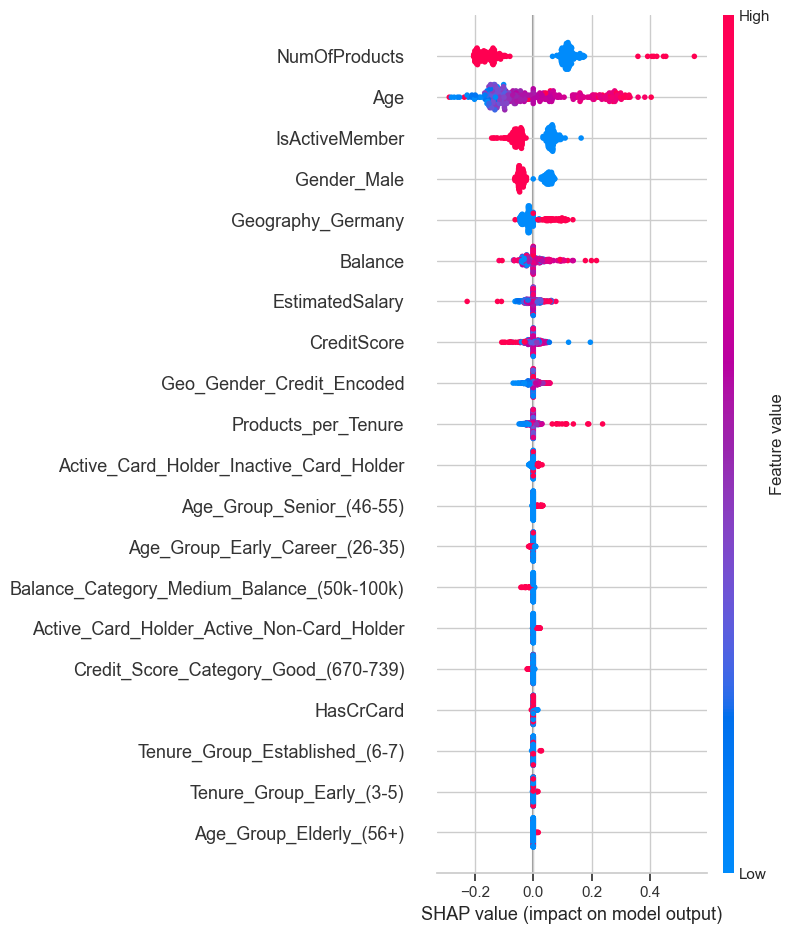

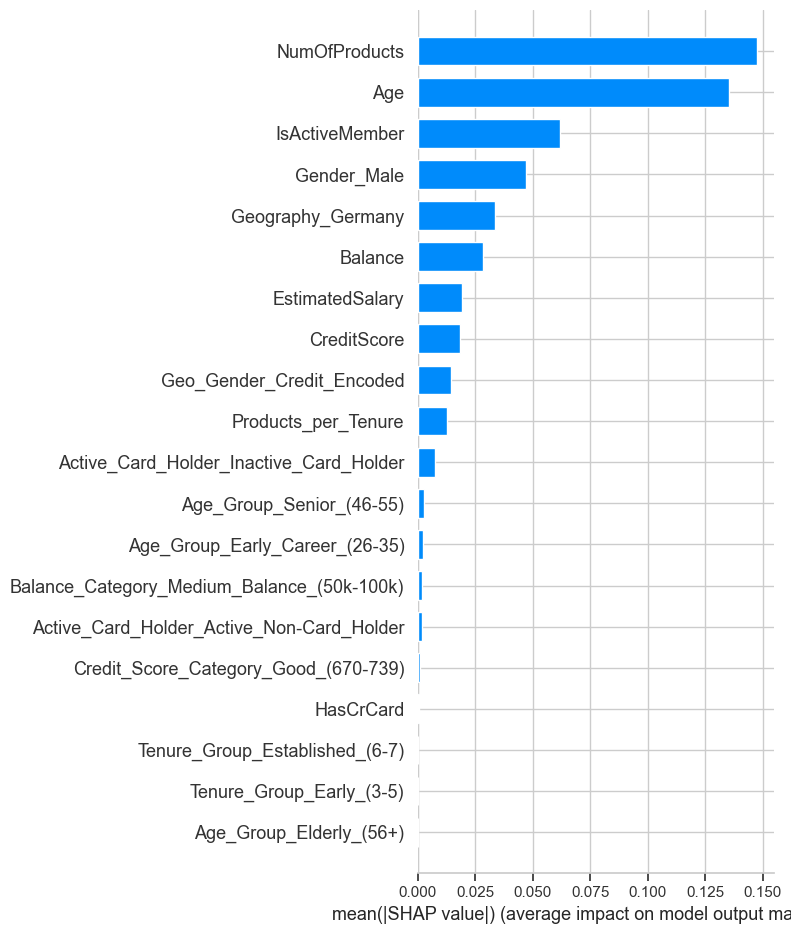


[SHAP] Local explanation for sample index: 40


,CreditScore,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,HasCrCard_WasMissing,IsActiveMember_WasMissing,Geography_WasMissing,...,Balance_Category_Low_Balance_(1-50k),Balance_Category_Medium_Balance_(50k-100k),Balance_Category_High_Balance_(100k+),Tenure_Group_Early_(3-5),Tenure_Group_Established_(6-7),Tenure_Group_Long-term_(8-10),Active_Card_Holder_Active_Non-Card_Holder,Active_Card_Holder_Inactive_Card_Holder,Active_Card_Holder_Inactive_Non-Card_Holder,Geo_Gender_Credit_Encoded
5386,-0.074627,0.948458,0.165445,3.0,-1.0,-1.0,-0.218316,-0.01,-0.01,-0.01,...,False,False,True,False,False,True,False,False,True,-0.181818


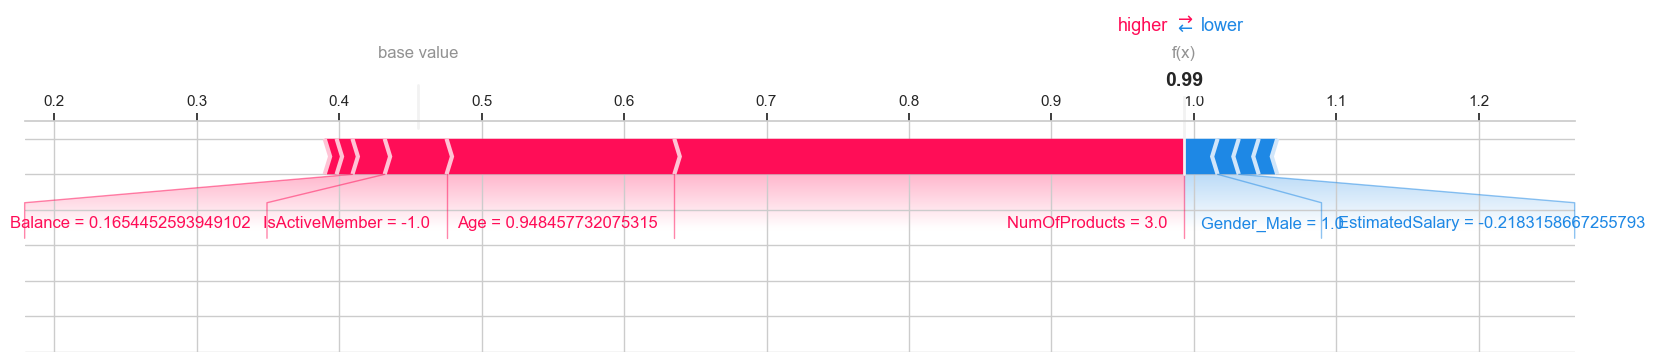

In [11]:
# =======================================================
# FINAL PRODUCTION-STYLE SHAP EXPLAINABILITY (XGBoost)
# =======================================================
# This section provides model interpretability using SHAP (SHapley Additive Explanations).
# It highlights both global feature importance and local (instance-level) explanations.
# The KernelExplainer is used here as a robust, model-agnostic fallback
# — especially reliable when TreeExplainer has compatibility issues with newer XGBoost builds.

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1️ Ensure DataFrame structure for clarity
# -----------------------------------------
# SHAP uses column names in plots — so we enforce DataFrame format for labeled visualizations.
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

# -----------------------------------------
# 2️ Background sample (SHAP baseline reference)
# -----------------------------------------
# The background dataset represents “average” samples used by SHAP to compute reference predictions.
# Using a subset speeds up calculations without sacrificing explanation quality.
n = len(X_train)
if n > 10000:
    bg_n = 200
elif n > 50:
    bg_n = n // 5
else:
    bg_n = n

background = X_train.sample(bg_n, random_state=42)
print(f"[SHAP] Using {bg_n} background rows for baseline.")

# -----------------------------------------
# 3️ Select subset of test samples for explanation
# -----------------------------------------
# SHAP doesn’t need to explain every single row — we use ~300 for stable global patterns.
test_n = 300 if len(X_test) > 300 else len(X_test)
X_shap = X_test.sample(test_n, random_state=42)
print(f"[SHAP] Explaining {test_n} test samples.")

# -----------------------------------------
# 4️ Define model prediction function
# -----------------------------------------
# The explainer calls this function repeatedly on synthetic perturbed samples.
predict_fn = lambda data: best_xgb.predict_proba(data)[:, 1]

# -----------------------------------------
# 5️ Create SHAP KernelExplainer
# -----------------------------------------
# KernelExplainer works for any model by treating it as a black box.
# It’s slower than TreeExplainer but universally compatible.
explainer = shap.KernelExplainer(predict_fn, background)

# -----------------------------------------
# 6️ Compute SHAP values
# -----------------------------------------
print("[SHAP] Computing SHAP values... this may take ~30–90 seconds depending on sample size.")
shap_values = explainer.shap_values(X_shap)
base_value = explainer.expected_value  # baseline (average model output)

# -----------------------------------------
# 7️ Global interpretability (feature-level)
# -----------------------------------------
# These plots summarize which features drive predictions across the entire dataset.
shap.initjs()

#  Beeswarm Plot — shows the distribution and direction of feature influence
shap.summary_plot(shap_values, X_shap, show=True)

#  Feature Importance Bar Plot — ranks features by mean |impact|
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)

# -----------------------------------------
# 8️ Local explanation (instance-level)
# -----------------------------------------
# Here we pick one of the most confident positive predictions
# to see what specific factors led to that decision.
probs = best_xgb.predict_proba(X_shap)[:, 1]
top_index = int(np.argmax(probs))

print(f"\n[SHAP] Local explanation for sample index: {top_index}")
display(X_shap.iloc[[top_index]])

#  Force Plot — visualizes positive and negative feature contributions
# (use matplotlib=True for static output in non-notebook environments)
shap.force_plot(base_value, shap_values[top_index], X_shap.iloc[top_index], matplotlib=True)


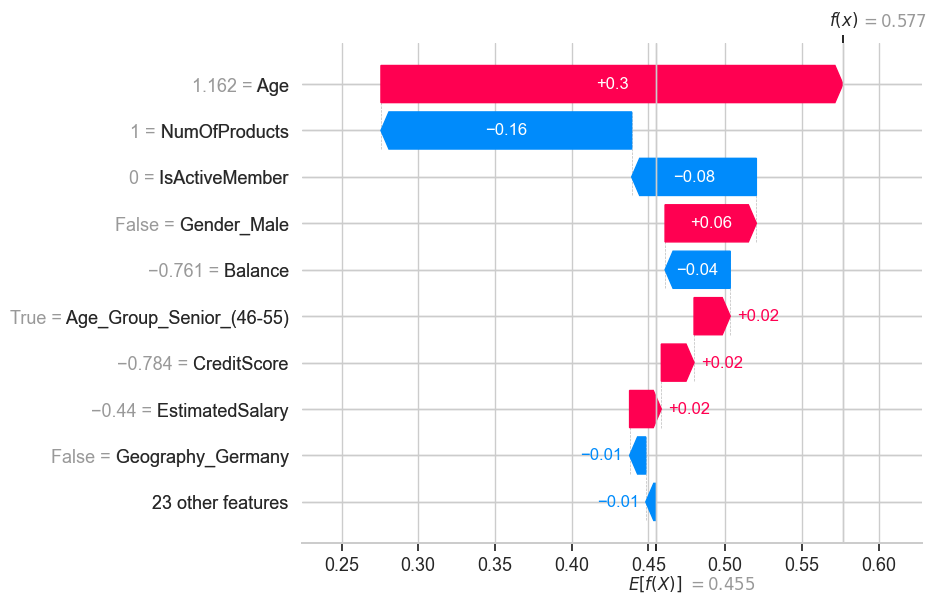

In [12]:
i=10

shap.plots.waterfall(shap.Explanation(values=shap_values[i],
                                      base_values=explainer.expected_value,
                                      data=X_shap.iloc[i],
                                      feature_names=X_shap.columns))
